In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.contingency_tables import StratifiedTable
df = pd.read_csv('./Cars93.csv')

In [3]:
type_counts = df['Type'].value_counts()
print(type_counts) 

Type
Midsize    22
Small      21
Compact    16
Sporty     14
Large      11
Van         9
Name: count, dtype: int64


In [4]:
type_proportions = df['Type'].value_counts(normalize=True)
print(type_proportions)

Type
Midsize    0.236559
Small      0.225806
Compact    0.172043
Sporty     0.150538
Large      0.118280
Van        0.096774
Name: proportion, dtype: float64


In [5]:
origin_counts = df['Origin'].value_counts()
print(origin_counts)

Origin
USA        48
non-USA    45
Name: count, dtype: int64


In [6]:
origin_proportions = df['Origin'].value_counts(normalize=True)
print(origin_proportions)

Origin
USA        0.516129
non-USA    0.483871
Name: proportion, dtype: float64


In [7]:
tab1 = pd.crosstab(df['Type'], df['Origin'])
print(tab1)

Origin   USA  non-USA
Type                 
Compact    7        9
Large     11        0
Midsize   10       12
Small      7       14
Sporty     8        6
Van        5        4


In [8]:
joint_proportions = pd.crosstab(df['Type'], df['Origin'], normalize=True) 
print(joint_proportions)

Origin        USA   non-USA
Type                       
Compact  0.075269  0.096774
Large    0.118280  0.000000
Midsize  0.107527  0.129032
Small    0.075269  0.150538
Sporty   0.086022  0.064516
Van      0.053763  0.043011


In [9]:
joint_proportions = pd.crosstab(df['Type'], df['Origin'], normalize=True) * 100
print(joint_proportions)

Origin         USA    non-USA
Type                         
Compact   7.526882   9.677419
Large    11.827957   0.000000
Midsize  10.752688  12.903226
Small     7.526882  15.053763
Sporty    8.602151   6.451613
Van       5.376344   4.301075


In [10]:
tab2 = pd.crosstab(df['Type'], df['Origin'], normalize='columns') * 100
print(tab2)

Origin         USA    non-USA
Type                         
Compact  14.583333  20.000000
Large    22.916667   0.000000
Midsize  20.833333  26.666667
Small    14.583333  31.111111
Sporty   16.666667  13.333333
Van      10.416667   8.888889


In [11]:
chi2, p_value, dof, expected = stats.chi2_contingency(tab1)
print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

Chi-squared statistic: 14.07985397126022
p-value: 0.015110051037674484
Degrees of freedom: 5
Expected frequencies:
[[ 8.25806452  7.74193548]
 [ 5.67741935  5.32258065]
 [11.35483871 10.64516129]
 [10.83870968 10.16129032]
 [ 7.22580645  6.77419355]
 [ 4.64516129  4.35483871]]


In [12]:
from scipy.stats import fisher_exact
X = np.array([[1, 8], [10, 4]]) # таблица сопряженности
print(X)
odds_ratio, p_value = fisher_exact(X)
print(f"Odds ratio: {odds_ratio}")
print(f"p-value: {p_value}")

[[ 1  8]
 [10  4]]
Odds ratio: 0.05
p-value: 0.00942253331538565


In [13]:
from statsmodels.stats.contingency_tables import Table
table = Table(tab1.values)
g_test = table.test_nominal_association()
print(f"G-test statistic: {g_test.statistic}")
print(f"p-value: {g_test.pvalue}")

G-test statistic: 12.691161665625469
p-value: 0.02645136755218025


In [14]:
three_way_table = pd.crosstab([df['Man.trans.avail'], df['Origin']], df['Type'])
print(three_way_table)

Type                     Compact  Large  Midsize  Small  Sporty  Van
Man.trans.avail Origin                                              
No              USA            2     11        9      0       0    4
                non-USA        0      0        4      0       0    2
Yes             USA            5      0        1      7       8    1
                non-USA        9      0        8     14       6    2


In [15]:
tables = []
man_trans_values = ['No', 'Yes']  # все возможные категории 'Man.trans.avail'
origin_values = ['USA', 'non-USA']  # все возможные категории 'Origin'

for car_type in df['Type'].unique():
    subset = df[df['Type'] == car_type]
    table = pd.crosstab(subset['Man.trans.avail'], subset['Origin'],
                        dropna=False).reindex(index=man_trans_values, columns=origin_values, fill_value=0)
    tables.append(table.values)
    print(table.values)

[[ 0  0]
 [ 7 14]]
[[9 4]
 [1 8]]
[[2 0]
 [5 9]]
[[11  0]
 [ 0  0]]
[[0 0]
 [8 6]]
[[4 2]
 [1 2]]


In [16]:
result = StratifiedTable(tables).test_null_odds()
print(f"CMH statistic: {result.statistic}")
print(f"p-value: {result.pvalue}")

CMH statistic: 9.948579057549887
p-value: 0.0016097359992230942


Задание

1

In [17]:
light = [13,47,27,52,24,38,23,35,48,34,29,31]
dark = [73,85,89,116,56,89,60,44,59,27,89,111]
very_dark = [3,8,2,4,9,3,2,7,1,5,10,4] 

In [18]:
df = pd.DataFrame({
    'light': light,
    'dark': dark,
    'very_dark': very_dark
})

print(df)

    light  dark  very_dark
0      13    73          3
1      47    85          8
2      27    89          2
3      52   116          4
4      24    56          9
5      38    89          3
6      23    60          2
7      35    44          7
8      48    59          1
9      34    27          5
10     29    89         10
11     31   111          4


In [19]:
chi2, p_value, dof, expected = stats.chi2_contingency(df.values)
print(f"Chi-squared statistic: {chi2}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

Chi-squared statistic: 82.85362497081506
p-value: 5.464405414438383e-09
Degrees of freedom: 22
Expected frequencies:
[[ 26.29992631  58.89609433   3.80397937]
 [ 41.3706706   92.64554164   5.98378777]
 [ 34.86956522  78.08695652   5.04347826]
 [ 50.82682388 113.82166544   7.35151069]
 [ 26.29992631  58.89609433   3.80397937]
 [ 38.4156227   86.02800295   5.55637436]
 [ 25.11790715  56.24907885   3.633014  ]
 [ 25.41341194  56.91083272   3.67575534]
 [ 31.91451732  71.46941783   4.61606485]
 [ 19.50331614  43.67575534   2.82092852]
 [ 37.82461312  84.70449521   5.47089167]
 [ 43.14369934  96.61606485   6.24023581]]


p < 0.05 нулевую гипаотезу об отсутствии различий в распределении окраски раковин отвеграем. распределение окраски раковин связано с принадлежностью к популяции.

2

In [31]:
drug = np.array([[[11, 10, 25, 27, 16, 22, 4, 10],
[14, 7, 5, 12, 2, 1, 14, 16]],
[[6, 0, 11, 12, 1, 0, 10, 10],
[1, 1, 4, 8, 4, 6, 2, 1]]])
centers = ['1', '2', '3', '4', '5', '6', '7', '8']
groups = ['Drug', 'Control']
responses = ['Success', 'Failure']

In [26]:
tables = []
for c in range(8):
    table = np.array([
        [drug[0, 0, c], drug[1, 0, c]],
        [drug[0, 1, c], drug[1, 1, c]]
    ])
    tables.append(table)

In [27]:
result = StratifiedTable(tables).test_null_odds()
print(f"CMH statistic: {result.statistic}")
print(f"p-value: {result.pvalue}")

CMH statistic: 0.04289049693270517
p-value: 0.8359315981894346


Анализ p > 0.05, значит не отвергаем нулевую гипотезу, следовательно, нет оснований утверждать, что в разных медицинских центрах результаты лечения статистически не различаются

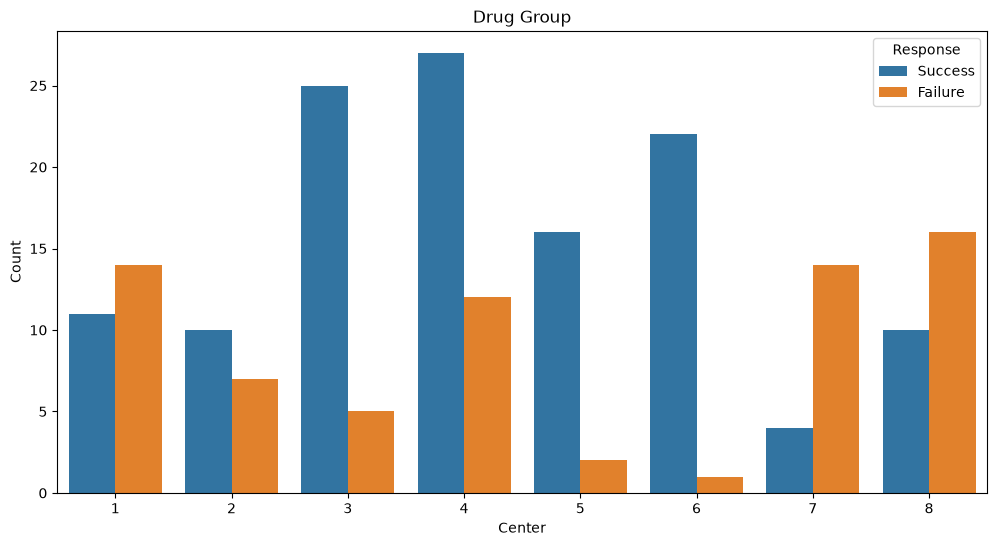

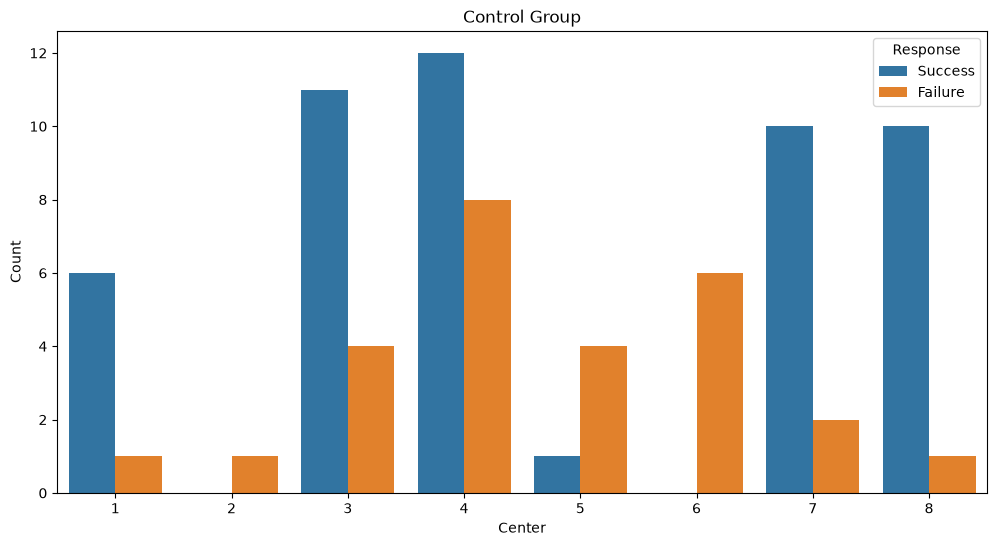

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
data_list = []
for i, center in enumerate(centers):
  for j, group in enumerate(groups):
    for k, response in enumerate(responses):
      value = drug[j, k, i]
      data_list.append({'Center': center, 'Group': group, 'Response': response, 'Value': value})
drug_df = pd.DataFrame(data_list)
plt.figure(figsize=(12, 6))
sns.barplot(x='Center', y='Value', hue='Response', data=drug_df[drug_df['Group'] == 'Drug'])
plt.title('Drug Group')
plt.ylabel('Count')
plt.show()
plt.figure(figsize=(12, 6))
sns.barplot(x='Center', y='Value', hue='Response', data=drug_df[drug_df['Group'] == 'Control'])
plt.title('Control Group')
plt.ylabel('Count')
plt.show()

На графиках показаны успешные и не очень случаи лечения, с препаратом и без. Визуально разница есть, но судя по p-value статистически не значимая